# FoundationStereo RGB result test: PyTorch vs ONNX Runtime CUDA

This notebook runs the same `left_rgb.png` / `right_rgb.png` pair through the PyTorch FS checkpoint and the exported FS ONNX model. Both paths use identical preprocessing and save their unpadded `960×600` float32 disparity maps.


In [1]:
from pathlib import Path
from time import perf_counter
import sys
import gc

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

# Supports launching Jupyter from the repository root or python_onnx_maker/.
REPO_ROOT = next(
    (candidate for candidate in (Path.cwd(), *Path.cwd().parents)
     if (candidate / "models/fs_960x608_iters32/fs.onnx").is_file()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Open this notebook inside the FS_realsense repository.")
REPO_ROOT = REPO_ROOT.resolve()
FS_ROOT = REPO_ROOT / "FoundationStereo"
if str(FS_ROOT) not in sys.path:
    sys.path.insert(0, str(FS_ROOT))

ONNX_PATH = REPO_ROOT / "models/fs_960x608_iters32/fs.onnx"
WEIGHTS_DIR = FS_ROOT / "weights/23-51-11"
LEFT_PATH = REPO_ROOT / "data/high_stereo_pair_test/left_rgb.png"
RIGHT_PATH = REPO_ROOT / "data/high_stereo_pair_test/right_rgb.png"
OUTPUT_DIR = Path("/tmp/fs_result_test")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# cudaMemGetInfo reports device-visible memory. It is useful for ONNX Runtime
# and TensorRT, whose allocations are not included in PyTorch's counters.
from cuda.bindings import runtime as cudart

def gpu_memory_mib():
    status, free_bytes, total_bytes = cudart.cudaMemGetInfo()
    if status != cudart.cudaError_t.cudaSuccess:
        raise RuntimeError(f"cudaMemGetInfo failed: {status}")
    return {"used_mib": (total_bytes - free_bytes) / 2**20,
            "free_mib": free_bytes / 2**20,
            "total_mib": total_bytes / 2**20}

def print_memory(label, before=None):
    now = gpu_memory_mib()
    message = f"{label}: GPU used={now['used_mib']:.1f} MiB, free={now['free_mib']:.1f} MiB"
    if before is not None:
        message += f", delta={now['used_mib'] - before['used_mib']:+.1f} MiB"
    print(message)
    return now

assert torch.cuda.is_available(), "PyTorch CUDA is required."
print("GPU:", torch.cuda.get_device_name(0))
print("ONNX:", ONNX_PATH)


GPU: NVIDIA RTX PRO 4000 Blackwell
ONNX: /home/liu4000/Desktop/FS_realsense/models/fs_960x608_iters32/fs.onnx


## Shared preprocessing

The model receives FP32 tensors in RGB channel order and the original 0–255 intensity range. The image content is resized to `960×600`, then replicate-padded to `960×608`.


In [2]:
MODEL_WIDTH, CONTENT_HEIGHT, MODEL_HEIGHT = 960, 600, 608
PAD_TOP, PAD_BOTTOM = 4, 4

def prepare_rgb(path: Path):
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    content = cv2.resize(image_rgb, (MODEL_WIDTH, CONTENT_HEIGHT), interpolation=cv2.INTER_LINEAR)
    padded = cv2.copyMakeBorder(content, PAD_TOP, PAD_BOTTOM, 0, 0, cv2.BORDER_REPLICATE)
    nchw = np.ascontiguousarray(padded.transpose(2, 0, 1)[None].astype(np.float32))
    return image_rgb, content, nchw

left_original, left_content, left_input = prepare_rgb(LEFT_PATH)
right_original, right_content, right_input = prepare_rgb(RIGHT_PATH)
assert left_input.shape == right_input.shape == (1, 3, 608, 960)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(left_content); axes[0].set_title("Left RGB: 960×600")
axes[1].imshow(right_content); axes[1].set_title("Right RGB: 960×600")
for axis in axes: axis.axis("off")


[ WARN:0@8.210] global loadsave.cpp:278 findDecoder imread_('/home/liu4000/Desktop/FS_realsense/data/high_stereo_pair_test/left_rgb.png'): can't open/read file: check file path/integrity


FileNotFoundError: /home/liu4000/Desktop/FS_realsense/data/high_stereo_pair_test/left_rgb.png

## PyTorch GPU reference

The autocast setting matches the wrapper used when exporting this ONNX model.


In [3]:
from omegaconf import OmegaConf
from core.foundation_stereo import FoundationStereo

pytorch_memory_before = print_memory("PyTorch before model load")
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

cfg = OmegaConf.load(WEIGHTS_DIR / "cfg.yaml")
cfg["vit_size"] = "vitl"
cfg["height"] = MODEL_HEIGHT
cfg["width"] = MODEL_WIDTH

model = FoundationStereo(cfg)
checkpoint = torch.load(WEIGHTS_DIR / "model_best_bp2.pth", weights_only=False, map_location="cpu")
model.load_state_dict(checkpoint["model"])
model = model.cuda().eval()

left_torch = torch.from_numpy(left_input).cuda(non_blocking=True)
right_torch = torch.from_numpy(right_input).cuda(non_blocking=True)
torch.cuda.synchronize()
start = perf_counter()
with torch.inference_mode(), torch.autocast(device_type="cuda", dtype=torch.float16):
    pytorch_padded = model.forward(left_torch, right_torch, iters=cfg.valid_iters, test_mode=True)
torch.cuda.synchronize()
pytorch_elapsed_ms = (perf_counter() - start) * 1000

pytorch_disp = np.ascontiguousarray(pytorch_padded.float().squeeze().cpu().numpy()[PAD_TOP:-PAD_BOTTOM, :])
assert pytorch_disp.shape == (600, 960)
np.save(OUTPUT_DIR / "pytorch_disparity_960x600.npy", pytorch_disp)
pytorch_memory_after = print_memory("PyTorch after inference", pytorch_memory_before)
print("PyTorch peak allocated={:.1f} MiB, peak reserved={:.1f} MiB".format(
    torch.cuda.max_memory_allocated() / 2**20,
    torch.cuda.max_memory_reserved() / 2**20,
))
print(f"PyTorch GPU: {pytorch_elapsed_ms:.2f} ms")

# Keep only the CPU NumPy disparity for the comparison cell.
del pytorch_padded, left_torch, right_torch, model, checkpoint
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print_memory("PyTorch after cleanup", pytorch_memory_before)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
PyTorch before model load: GPU used=781.7 MiB, free=23203.8 MiB


Using cache found in /home/liu4000/.cache/torch/hub/facebookresearch_dinov2_main
/home/liu4000/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/home/liu4000/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/liu4000/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")
using MLP layer as FFN
/home/liu4000/Desktop/FS_realsense/FoundationStereo/core/foundation_stereo.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):
/home/liu4000/Desktop/FS_realsense/FoundationStereo/core/submodule.py:390:

PyTorch after inference: GPU used=4789.7 MiB, free=19195.8 MiB, delta=+4008.0 MiB
PyTorch peak allocated=3163.2 MiB, peak reserved=3884.0 MiB
PyTorch GPU: 1925.77 ms
PyTorch after cleanup: GPU used=937.7 MiB, free=23047.8 MiB, delta=+156.0 MiB


/home/liu4000/Desktop/FS_realsense/FoundationStereo/core/foundation_stereo.py:191: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):


{'used_mib': 937.6875, 'free_mib': 23047.75, 'total_mib': 23985.4375}

## ONNX Runtime CUDA

The assertion prevents silent CPU fallback. Loading the PyTorch model first also makes its CUDA/cuDNN libraries available to ONNX Runtime in this environment.


In [4]:
import onnxruntime as ort

onnx_memory_before = print_memory("ONNX Runtime before session")
ort.set_default_logger_severity(3)
ort.preload_dlls()  # load cuDNN/CUDA libraries bundled in this conda environment
session_options = ort.SessionOptions()
session_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
session_options.log_severity_level = 3
session = ort.InferenceSession(
    str(ONNX_PATH),
    sess_options=session_options,
    providers=[("CUDAExecutionProvider", {"device_id": 0}), "CPUExecutionProvider"],
)
print("Active providers:", session.get_providers())
if session.get_providers()[0] != "CUDAExecutionProvider":
    raise RuntimeError("ONNX Runtime CUDA provider was not activated; do not compare a CPU fallback.")

# Warmup initializes provider allocations and CUDA kernels.
_ = session.run(["disp"], {"left": left_input, "right": right_input})
torch.cuda.synchronize()
start = perf_counter()
onnx_padded = session.run(["disp"], {"left": left_input, "right": right_input})[0]
torch.cuda.synchronize()
onnx_elapsed_ms = (perf_counter() - start) * 1000

onnx_disp = np.ascontiguousarray(onnx_padded[0, 0, PAD_TOP:-PAD_BOTTOM, :])
assert onnx_disp.shape == (600, 960) and onnx_disp.dtype == np.float32
np.save(OUTPUT_DIR / "onnx_runtime_cuda_disparity_960x600.npy", onnx_disp)
print_memory("ONNX Runtime after inference", onnx_memory_before)
print(f"ONNX Runtime CUDA: {onnx_elapsed_ms:.2f} ms")

# ORT owns its CUDA allocations through the session object.
del _, onnx_padded, session, session_options
gc.collect()
torch.cuda.synchronize()
torch.cuda.empty_cache()
print_memory("ONNX Runtime after cleanup", onnx_memory_before)


ONNX Runtime before session: GPU used=937.7 MiB, free=23047.8 MiB
Active providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
ONNX Runtime after inference: GPU used=12351.7 MiB, free=11633.8 MiB, delta=+11414.0 MiB
ONNX Runtime CUDA: 2215.34 ms
ONNX Runtime after cleanup: GPU used=959.7 MiB, free=23025.8 MiB, delta=+22.0 MiB


{'used_mib': 959.6875, 'free_mib': 23025.75, 'total_mib': 23985.4375}

## TensorRT Python inference

This loads the deployed `fs.engine` directly through the locally installed TensorRT 10.16 bindings. It sends the same `left_input` and `right_input` tensors used by PyTorch and ONNX Runtime, then removes the four padded rows at the top and bottom.


In [5]:
# TensorRT 10.16 is installed by the system package under this Python 3.12 path.
SYSTEM_PYTHON_PACKAGES = "/usr/lib/python3.12/dist-packages"
if SYSTEM_PYTHON_PACKAGES not in sys.path:
    sys.path.append(SYSTEM_PYTHON_PACKAGES)

import tensorrt as trt

ENGINE_PATH = REPO_ROOT / "models/fs_960x608_iters32/fs.engine"

def check_cuda(result, label):
    if result[0] != cudart.cudaError_t.cudaSuccess:
        raise RuntimeError(f"{label}: {result[0]}")
    return result[1:] if len(result) > 1 else None

tensorrt_memory_before = print_memory("TensorRT before engine load")
logger = trt.Logger(trt.Logger.ERROR)
runtime = trt.Runtime(logger)
engine = runtime.deserialize_cuda_engine(ENGINE_PATH.read_bytes())
if engine is None:
    raise RuntimeError(f"TensorRT could not deserialize {ENGINE_PATH}")
context = engine.create_execution_context()
if context is None:
    raise RuntimeError("TensorRT could not create an execution context")

expected_shapes = {"left": (1, 3, 608, 960), "right": (1, 3, 608, 960), "disp": (1, 1, 608, 960)}
actual_shapes = {name: tuple(engine.get_tensor_shape(name)) for name in expected_shapes}
assert actual_shapes == expected_shapes, actual_shapes

trt_padded = np.empty((1, 1, 608, 960), dtype=np.float32)
stream = check_cuda(cudart.cudaStreamCreate(), "create CUDA stream")[0]
d_left = check_cuda(cudart.cudaMalloc(left_input.nbytes), "allocate TensorRT left input")[0]
d_right = check_cuda(cudart.cudaMalloc(right_input.nbytes), "allocate TensorRT right input")[0]
d_disp = check_cuda(cudart.cudaMalloc(trt_padded.nbytes), "allocate TensorRT output")[0]
try:
    assert context.set_tensor_address("left", int(d_left))
    assert context.set_tensor_address("right", int(d_right))
    assert context.set_tensor_address("disp", int(d_disp))

    # Warmup is intentionally excluded from the timing.
    check_cuda(cudart.cudaMemcpyAsync(d_left, left_input.ctypes.data, left_input.nbytes,
                                     cudart.cudaMemcpyKind.cudaMemcpyHostToDevice, stream), "warmup left H2D")
    check_cuda(cudart.cudaMemcpyAsync(d_right, right_input.ctypes.data, right_input.nbytes,
                                     cudart.cudaMemcpyKind.cudaMemcpyHostToDevice, stream), "warmup right H2D")
    assert context.execute_async_v3(stream)
    check_cuda(cudart.cudaStreamSynchronize(stream), "warmup synchronize")

    start = perf_counter()
    check_cuda(cudart.cudaMemcpyAsync(d_left, left_input.ctypes.data, left_input.nbytes,
                                     cudart.cudaMemcpyKind.cudaMemcpyHostToDevice, stream), "left H2D")
    check_cuda(cudart.cudaMemcpyAsync(d_right, right_input.ctypes.data, right_input.nbytes,
                                     cudart.cudaMemcpyKind.cudaMemcpyHostToDevice, stream), "right H2D")
    assert context.execute_async_v3(stream)
    check_cuda(cudart.cudaMemcpyAsync(trt_padded.ctypes.data, d_disp, trt_padded.nbytes,
                                     cudart.cudaMemcpyKind.cudaMemcpyDeviceToHost, stream), "disparity D2H")
    check_cuda(cudart.cudaStreamSynchronize(stream), "TensorRT synchronize")
    tensorrt_elapsed_ms = (perf_counter() - start) * 1000
finally:
    cudart.cudaFree(d_left)
    cudart.cudaFree(d_right)
    cudart.cudaFree(d_disp)
    cudart.cudaStreamDestroy(stream)

tensorrt_disp = np.ascontiguousarray(trt_padded[0, 0, PAD_TOP:-PAD_BOTTOM, :])
assert tensorrt_disp.shape == (600, 960) and tensorrt_disp.dtype == np.float32
np.save(OUTPUT_DIR / "tensorrt_disparity_960x600.npy", tensorrt_disp)
print_memory("TensorRT after inference", tensorrt_memory_before)
print("TensorRT version:", trt.__version__)
print(f"TensorRT end-to-end GPU path: {tensorrt_elapsed_ms:.2f} ms")

# trt_padded and tensorrt_disp are CPU arrays. Release all TensorRT GPU owners.
del context, engine, runtime, logger, trt_padded
gc.collect()
torch.cuda.synchronize()
torch.cuda.empty_cache()
print_memory("TensorRT after cleanup", tensorrt_memory_before)


TensorRT before engine load: GPU used=959.7 MiB, free=23025.8 MiB
TensorRT after inference: GPU used=6005.7 MiB, free=17979.8 MiB, delta=+5046.0 MiB
TensorRT version: 10.16.1.11
TensorRT end-to-end GPU path: 1120.88 ms
TensorRT after cleanup: GPU used=959.7 MiB, free=23025.8 MiB, delta=+0.0 MiB


{'used_mib': 959.6875, 'free_mib': 23025.75, 'total_mib': 23985.4375}

## Compare and visualize

The colormap uses a shared 99th-percentile limit. This avoids a few very large disparity values flattening the visible structure. TensorRT timing includes H2D, inference, and D2H; PyTorch and ONNX Runtime timings include their respective full calls.


{'pytorch_ms': 1925.7740069997453, 'onnx_runtime_cuda_ms': 2215.343743999256, 'tensorrt_end_to_end_ms': 1120.8824380000806, 'pytorch_vs_onnx': {'mean_abs_error': 0.8278908133506775, 'p99_abs_error': 13.545751571655273, 'max_abs_error': 216.090576171875}, 'tensorrt_vs_onnx': {'mean_abs_error': 1.0889874696731567, 'p99_abs_error': 13.480237007141113, 'max_abs_error': 207.3336181640625}, 'tensorrt_vs_pytorch': {'mean_abs_error': 0.6288328766822815, 'p99_abs_error': 5.680916786193848, 'max_abs_error': 207.88290405273438}, 'output_dir': '/tmp/fs_result_test'}


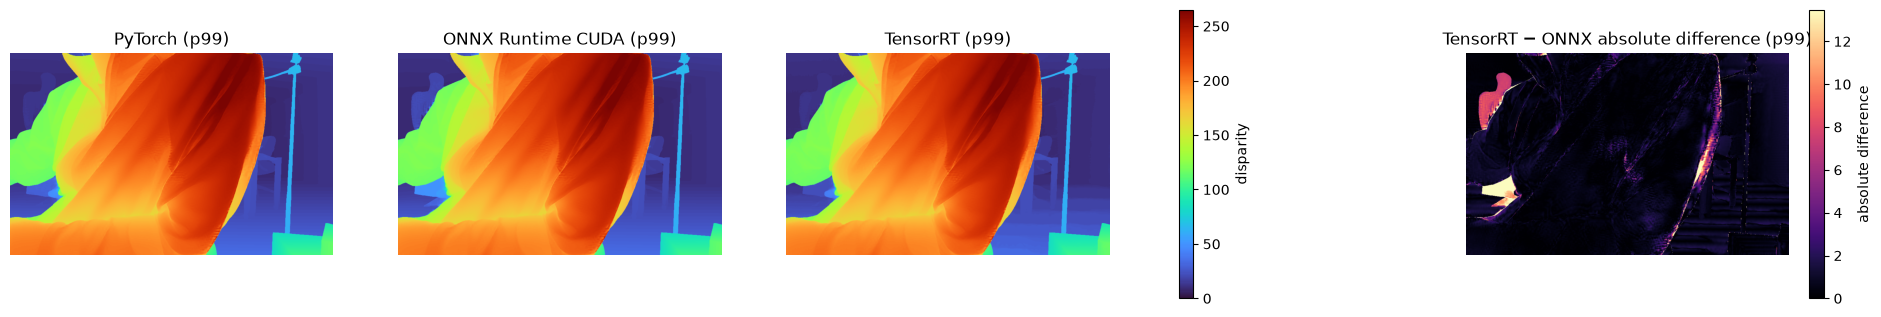

In [6]:
def error_metrics(reference, candidate):
    difference = np.abs(reference - candidate)
    return {
        "mean_abs_error": float(difference.mean()),
        "p99_abs_error": float(np.percentile(difference, 99)),
        "max_abs_error": float(difference.max()),
    }

trt_vs_onnx = np.abs(tensorrt_disp - onnx_disp)
print({
    "pytorch_ms": float(pytorch_elapsed_ms),
    "onnx_runtime_cuda_ms": float(onnx_elapsed_ms),
    "tensorrt_end_to_end_ms": float(tensorrt_elapsed_ms),
    "pytorch_vs_onnx": error_metrics(pytorch_disp, onnx_disp),
    "tensorrt_vs_onnx": error_metrics(tensorrt_disp, onnx_disp),
    "tensorrt_vs_pytorch": error_metrics(tensorrt_disp, pytorch_disp),
    "output_dir": str(OUTPUT_DIR),
})

def display_limit(*arrays):
    finite = np.concatenate([array[np.isfinite(array)].ravel() for array in arrays])
    return float(np.percentile(finite, 99))

limit = display_limit(pytorch_disp, onnx_disp, tensorrt_disp)
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
for axis, values, title in zip(
    axes[:3],
    (pytorch_disp, onnx_disp, tensorrt_disp),
    ("PyTorch (p99)", "ONNX Runtime CUDA (p99)", "TensorRT (p99)"),
):
    image = axis.imshow(values, cmap="turbo", vmin=0, vmax=limit)
    axis.set_title(title)
    axis.axis("off")
error_image = axes[3].imshow(
    trt_vs_onnx, cmap="magma", vmin=0, vmax=np.percentile(trt_vs_onnx, 99)
)
axes[3].set_title("TensorRT − ONNX absolute difference (p99)")
axes[3].axis("off")
fig.colorbar(image, ax=axes[:3], shrink=0.75, label="disparity")
fig.colorbar(error_image, ax=axes[3], shrink=0.75, label="absolute difference")
plt.show()
